# Scene Mapping Exploration

Walks through all scene classification logic step by step.

**Kernel:** Use the `.venv` kernel (Poetry env), NOT `mr_env`.  
`cloudpathlib` and `sklearn` are only installed in `.venv`.

Three places in the codebase do scene mapping:
1. `prod/std/standard_method.py` — defines `SCENE_TYPES` (the 5 Loeb bins, authoritative)
2. `unfiltered_radiances/unfiltering.py` — `classify_scene_cloud()` — runtime path (FMATCH-CAM → scene index per sample)
3. `tp7/modtran6.py` — `CERES_SCENE_MAP` + `_determine_scene_and_cloud()` — coefficient generation path (M6 file scene ID → scene string)

In [1]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

from prod.std.standard_method import SCENE_TYPES, CLOUD_VALUES
from unfiltered_radiances.unfiltering import (
    _CLOUD_FRACTION_THRESHOLD, _DCC_OT_THRESHOLD,
    _IGBP_OCEAN, _IGBP_SNOW,
    _IDX_LAND, _IDX_CLO_OCE, _IDX_CLR_OCE, _IDX_SNOW, _IDX_DCC,
    classify_scene_cloud,
)
from tp7.modtran6 import CERES_SCENE_MAP

DATA_DIR = Path('../../data/example_data')
CAM_FILE = DATA_DIR / 'LIBERA_ANC_FMATCH-CAM_V0-1-0_20280212T033945_20280212T033954_R26169165032.nc'
M6_FILE  = Path('../../data/Modtran_6_data/FV3_Modtran6_IO_v5_write_v2_scene_1.nc')

print('SCENE_TYPES:', SCENE_TYPES)
print('CLOUD_VALUES:', CLOUD_VALUES)

SCENE_TYPES: ['Land', 'Cloudy Ocean', 'Clear Ocean', 'Snow', 'Deep Convective Cloud']
CLOUD_VALUES: [0, 1]


## IGBP Surface Type Reference

All 20 IGBP types and how they map to the 5 Loeb scene bins under current logic.

| IGBP ID | Name | → Scene |
|---------|------|---------|
| 1  | Evergreen Needleleaf Forest | Land |
| 2  | Evergreen Broadleaf Forest  | Land |
| 3  | Deciduous Needleleaf Forest | Land |
| 4  | Deciduous Broadleaf Forest  | Land |
| 5  | Mixed Forests               | Land |
| 6  | Closed Shrublands           | Land |
| 7  | Open Shrublands             | Land |
| 8  | Woody Savannas              | Land |
| 9  | Savannas                    | Land |
| 10 | Grasslands                  | Land |
| 11 | Permanent Wetlands          | Land |
| 12 | Croplands                   | Land |
| 13 | Urban and Built-Up          | Land |
| 14 | Cropland/Natural Veg Mosaic | Land |
| 15 | **Snow and Ice**            | **Snow** |
| 16 | Barren or Sparsely Veg      | Land |
| 17 | **Water Bodies**            | **Cloudy Ocean** or **Clear Ocean** (split by cloud fraction) |
| 18 | Wooded Tundra               | **Snow** *(provisional — pending science review)* |
| 19 | Mixed Tundra                | **Snow** *(provisional — pending science review)* |
| 20 | Barren Tundra               | **Snow** *(provisional — pending science review)* |

Additional overrides (applied regardless of IGBP):
- `nise_permanent_ice > 0.5` → **Snow**
- `nise_dry_snow_on_land > 0.5` → **Snow**
- `nise_sea_ice_concentration > 0.5` → **Snow** *(provisional — pending science review)*
- `cloud_fraction >= 0.10 AND cloud_optical_thickness > 10.0` → **DCC** (highest priority, overrides all)

## 1. Open FMATCH-CAM File

In [2]:
cam_ds = xr.open_dataset(CAM_FILE)
print('Variables:', list(cam_ds.variables))
cam_ds

Variables: ['latitude', 'longitude', 'altitude', 'solar_zenith_angle', 'viewing_zenith_angle', 'relative_azimuth_angle', 'sunglint_angle', 'era5_wind_u10', 'era5_wind_v10', 'igbp_surface_type', 'nise_sea_ice_concentration', 'nise_no_ice_or_snow', 'nise_permanent_ice', 'nise_dry_snow_on_land', 'nise_snow_ice_missing', 'viirs_brdf_brdf_shortwave_fiso', 'viirs_brdf_brdf_shortwave_fvol', 'viirs_brdf_brdf_shortwave_fgeo', 'viirs_brdf_brdf_vis_fiso', 'viirs_brdf_brdf_vis_fvol', 'viirs_brdf_brdf_vis_fgeo', 'viirs_brdf_brdf_nir_fiso', 'viirs_brdf_brdf_nir_fvol', 'viirs_brdf_brdf_nir_fgeo', 'viirs_cloud_cloud_fraction', 'viirs_cloud_cloud_optical_thickness', 'viirs_cloud_cloud_top_pressure', 'psf_bbox_lat_min', 'psf_bbox_lat_max', 'psf_bbox_lon_min', 'psf_bbox_lon_max', 'psf_coverage_fraction', 'q_flags', 'RADIOMETER_TIME']


<xarray.Dataset> Size: 142kB
Dimensions:                              (RADIOMETER_TIME: 1000)
Coordinates:
  * RADIOMETER_TIME                      (RADIOMETER_TIME) datetime64[ns] 8kB ...
Data variables: (12/33)
    latitude                             (RADIOMETER_TIME) float32 4kB ...
    longitude                            (RADIOMETER_TIME) float32 4kB ...
    altitude                             (RADIOMETER_TIME) float32 4kB ...
    solar_zenith_angle                   (RADIOMETER_TIME) float32 4kB ...
    viewing_zenith_angle                 (RADIOMETER_TIME) float32 4kB ...
    relative_azimuth_angle               (RADIOMETER_TIME) float32 4kB ...
    ...                                   ...
    psf_bbox_lat_min                     (RADIOMETER_TIME) float32 4kB ...
    psf_bbox_lat_max                     (RADIOMETER_TIME) float32 4kB ...
    psf_bbox_lon_min                     (RADIOMETER_TIME) float32 4kB ...
    psf_bbox_lon_max                     (RADIOMETER_TIME) float32 4kB ...
    psf_coverage_fraction                (RADIOMETER_TIME) float32 4kB ...
    q_flags                              (RADIOMETER_TIME) int64 8kB ...
Attributes:
    ProductID:          FMATCH-CAM
    algorithm_version:  0.1.0
    date_created:       2026-06-18T16:50:32.650703+00:00
    input_files:        SYNTHETIC EXAMPLE - no real input files were used
    Format:             NetCDF-4
    Conventions:        CF-1.8
    ProjectLongName:    Libera
    ProjectShortName:   Libera
    PlatformLongName:   TBD
    PlatformShortName:  NOAA-22

## 2. Extract and Inspect Each Classification Input

In [3]:
igbp     = cam_ds['igbp_surface_type'].values.astype(int)
cf       = cam_ds['viirs_cloud_cloud_fraction'].values
cot      = cam_ds['viirs_cloud_cloud_optical_thickness'].values
perm_ice = cam_ds['nise_permanent_ice'].values
dry_snow = cam_ds['nise_dry_snow_on_land'].values
sea_ice  = cam_ds['nise_sea_ice_concentration'].values

n = len(igbp)
print(f'Samples: {n}')
print()

for name, arr in [
    ('igbp_surface_type', igbp),
    ('cloud_fraction', cf),
    ('cloud_optical_thickness', cot),
    ('nise_permanent_ice', perm_ice),
    ('nise_dry_snow_on_land', dry_snow),
    ('nise_sea_ice_concentration', sea_ice),
]:
    print(f'{name:35s}  dtype={arr.dtype}  min={arr.min():.3f}  max={arr.max():.3f}  mean={arr.mean():.3f}')

Samples: 1000

igbp_surface_type                    dtype=int64  min=1.000  max=20.000  mean=10.451
cloud_fraction                       dtype=float32  min=0.001  max=0.999  mean=0.514
cloud_optical_thickness              dtype=float32  min=0.001  max=0.999  mean=0.506
nise_permanent_ice                   dtype=float32  min=0.000  max=0.999  mean=0.508
nise_dry_snow_on_land                dtype=float32  min=0.001  max=0.998  mean=0.487
nise_sea_ice_concentration           dtype=float32  min=0.001  max=0.999  mean=0.512


## 3. IGBP Type Distribution

In [4]:
unique_igbp, igbp_counts = np.unique(igbp, return_counts=True)

igbp_names = {
    1: 'Evergreen Needleleaf', 2: 'Evergreen Broadleaf', 3: 'Deciduous Needleleaf',
    4: 'Deciduous Broadleaf', 5: 'Mixed Forest', 6: 'Closed Shrubland',
    7: 'Open Shrubland', 8: 'Woody Savanna', 9: 'Savanna', 10: 'Grassland',
    11: 'Permanent Wetland', 12: 'Cropland', 13: 'Urban', 14: 'Cropland/Veg Mosaic',
    15: 'Snow and Ice', 16: 'Barren', 17: 'Water Bodies',
    18: 'Wooded Tundra', 19: 'Mixed Tundra', 20: 'Barren Tundra',
}

df = pd.DataFrame({
    'igbp_id': unique_igbp,
    'name': [igbp_names.get(i, 'Unknown') for i in unique_igbp],
    'count': igbp_counts,
})
df

,igbp_id,name,count
0,1,Evergreen Needleleaf,48
1,2,Evergreen Broadleaf,68
2,3,Deciduous Needleleaf,38
3,4,Deciduous Broadleaf,50
4,5,Mixed Forest,53
5,6,Closed Shrubland,57
6,7,Open Shrubland,46
7,8,Woody Savanna,46
8,9,Savanna,53
9,10,Grassland,48


## 4. Step Through Classification — Priority 1: DCC

`cloud_fraction >= 0.10 AND cloud_optical_thickness > 10.0` → overrides all other scene types

DCC threshold: cloud_fraction >= 0.1, cloud_optical_thickness > 10.0
DCC samples: 0 / 1000  (0.0%)


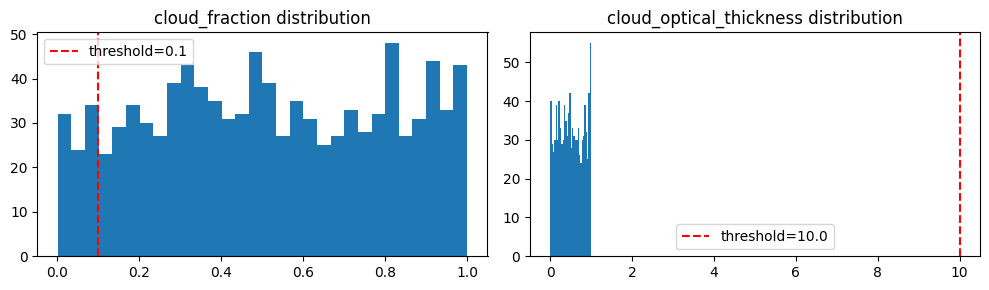

In [5]:
dcc = (cf >= _CLOUD_FRACTION_THRESHOLD) & (cot > _DCC_OT_THRESHOLD)
print(f'DCC threshold: cloud_fraction >= {_CLOUD_FRACTION_THRESHOLD}, cloud_optical_thickness > {_DCC_OT_THRESHOLD}')
print(f'DCC samples: {dcc.sum()} / {n}  ({100*dcc.mean():.1f}%)')

# Show the cf/cot distributions to understand why DCC count is what it is
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(cf, bins=30)
axes[0].axvline(_CLOUD_FRACTION_THRESHOLD, color='r', linestyle='--', label=f'threshold={_CLOUD_FRACTION_THRESHOLD}')
axes[0].set_title('cloud_fraction distribution')
axes[0].legend()
axes[1].hist(cot, bins=30)
axes[1].axvline(_DCC_OT_THRESHOLD, color='r', linestyle='--', label=f'threshold={_DCC_OT_THRESHOLD}')
axes[1].set_title('cloud_optical_thickness distribution')
axes[1].legend()
plt.tight_layout()
plt.show()

## 5. Step Through Classification — Priority 2: Snow

Five conditions (any one is sufficient), applied to samples not already DCC.

In [6]:
snow_conditions = [
    ('IGBP 15 (Snow and Ice)', igbp == _IGBP_SNOW),
    ('perm_ice > 0.5',          perm_ice > 0.5),
    ('dry_snow > 0.5',          dry_snow > 0.5),
    ('sea_ice > 0.5 [provisional]', sea_ice > 0.5),
    ('tundra IGBP 18-20 [provisional]', (igbp >= 18) & (igbp <= 20)),
]

print('Snow sub-conditions (excluding DCC samples):')
for label, mask in snow_conditions:
    n_fired = int((~dcc & mask).sum())
    print(f'  {label:45s}  {n_fired:5d} samples')

snow = ~dcc & (
    (igbp == _IGBP_SNOW) |
    (perm_ice > 0.5) |
    (dry_snow > 0.5) |
    (sea_ice > 0.5) |
    ((igbp >= 18) & (igbp <= 20))
)
print(f'\nTotal Snow (union of all conditions, excl. DCC): {snow.sum()} / {n}  ({100*snow.mean():.1f}%)')

Snow sub-conditions (excluding DCC samples):
  IGBP 15 (Snow and Ice)                            58 samples
  perm_ice > 0.5                                   523 samples
  dry_snow > 0.5                                   481 samples
  sea_ice > 0.5 [provisional]                      518 samples
  tundra IGBP 18-20 [provisional]                  159 samples

Total Snow (union of all conditions, excl. DCC): 915 / 1000  (91.5%)


## 6. Step Through Classification — Priority 3: Ocean

`IGBP == 17`, not already DCC or Snow → split by cloud fraction into Cloudy/Clear Ocean.

In [7]:
ocean        = ~dcc & ~snow & (igbp == _IGBP_OCEAN)
cloudy_ocean = ocean & (cf > _CLOUD_FRACTION_THRESHOLD)
clear_ocean  = ocean & (cf <= _CLOUD_FRACTION_THRESHOLD)

print(f'IGBP 17 samples not DCC/Snow: {ocean.sum()}')
print(f'  Cloudy Ocean (cf > {_CLOUD_FRACTION_THRESHOLD}): {cloudy_ocean.sum()}')
print(f'  Clear Ocean  (cf <= {_CLOUD_FRACTION_THRESHOLD}): {clear_ocean.sum()}')

IGBP 17 samples not DCC/Snow: 7
  Cloudy Ocean (cf > 0.1): 6
  Clear Ocean  (cf <= 0.1): 1


## 7. Step Through Classification — Priority 4: Land

Everything not DCC, Snow, or Ocean defaults to Land.

In [8]:
land = ~dcc & ~snow & ~ocean
print(f'Land: {land.sum()} / {n}  ({100*land.mean():.1f}%)')

# What IGBP types ended up as Land?
land_igbp, land_igbp_counts = np.unique(igbp[land], return_counts=True)
pd.DataFrame({
    'igbp_id': land_igbp,
    'name': [igbp_names.get(i, 'Unknown') for i in land_igbp],
    'count': land_igbp_counts,
})

Land: 78 / 1000  (7.8%)


,igbp_id,name,count
0,1,Evergreen Needleleaf,4
1,2,Evergreen Broadleaf,12
2,3,Deciduous Needleleaf,1
3,4,Deciduous Broadleaf,6
4,5,Mixed Forest,10
5,6,Closed Shrubland,2
6,7,Open Shrubland,4
7,8,Woody Savanna,4
8,9,Savanna,5
9,10,Grassland,3


## 8. Call the Full Function and Cross-Check

In [9]:
scene_idx, cloud = classify_scene_cloud(cam_ds)

counts = {SCENE_TYPES[i]: int((scene_idx == i).sum()) for i in range(len(SCENE_TYPES))}
print('Scene counts from classify_scene_cloud():')
for name, cnt in counts.items():
    print(f'  {name:30s}: {cnt}')

print()
print('Manual step-through:')
manual = {
    'Land':                  int(land.sum()),
    'Cloudy Ocean':          int(cloudy_ocean.sum()),
    'Clear Ocean':           int(clear_ocean.sum()),
    'Snow':                  int(snow.sum()),
    'Deep Convective Cloud': int(dcc.sum()),
}
for name, cnt in manual.items():
    match = '✓' if counts[name] == cnt else '✗ MISMATCH'
    print(f'  {name:30s}: {cnt}  {match}')

Scene counts from classify_scene_cloud():
  Land                          : 78
  Cloudy Ocean                  : 6
  Clear Ocean                   : 1
  Snow                          : 915
  Deep Convective Cloud         : 0

Manual step-through:
  Land                          : 78  ✓
  Cloudy Ocean                  : 6  ✓
  Clear Ocean                   : 1  ✓
  Snow                          : 915  ✓
  Deep Convective Cloud         : 0  ✓


## 9. Scene Distribution Plot

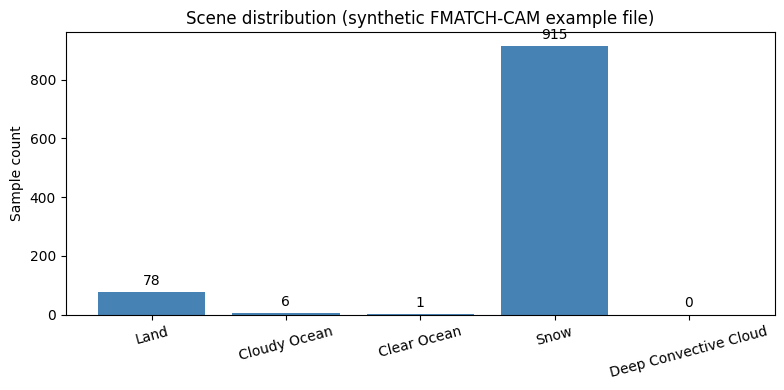

Note: Nearly all samples are Snow because synthetic NISE values are uniformly ~0.5.
Real FMATCH-CAM data will distribute across all 5 scene types.


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(list(counts.keys()), list(counts.values()), color='steelblue')
ax.bar_label(bars, padding=3)
ax.set_title('Scene distribution (synthetic FMATCH-CAM example file)')
ax.set_ylabel('Sample count')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print('Note: Nearly all samples are Snow because synthetic NISE values are uniformly ~0.5.')
print('Real FMATCH-CAM data will distribute across all 5 scene types.')

## 10. CERES_SCENE_MAP — M6 Coefficient Generation Path

This is a **separate** mapping used only during coefficient generation from MODTRAN 6 files (`tp7/modtran6.py`).  
It maps a MODTRAN 6 file's `CERES_TRMM_Scene_ID` integer → one of the 5 Loeb scene strings.  
The runtime inference path (`classify_scene_cloud()` above) does **not** use this map.

Currently only 2 of 5 scenes are mapped — Land, Snow, and DCC scene IDs in M6 files are unknown until real SAE data is accessible.

In [11]:
print('CERES_SCENE_MAP (maps M6 CERES_TRMM_Scene_ID → Loeb scene):')
for scene_id, name in sorted(CERES_SCENE_MAP.items()):
    print(f'  {scene_id:3d} → {name}')

missing = [s for s in SCENE_TYPES if s not in CERES_SCENE_MAP.values()]
print(f'\nNot yet mapped (need real M6 data from SAE): {missing}')

CERES_SCENE_MAP (maps M6 CERES_TRMM_Scene_ID → Loeb scene):
    5 → Clear Ocean
   18 → Cloudy Ocean

Not yet mapped (need real M6 data from SAE): ['Land', 'Snow', 'Deep Convective Cloud']


## 11. M6 File — `_determine_scene_and_cloud()` Step-Through

Opens one MODTRAN 6 example file and manually replicates what `Modtran6NC._determine_scene_and_cloud()` does.  
Each M6 file is a single scene, so this is a scalar lookup rather than a per-sample array.

In [12]:
ds_m6 = xr.open_dataset(M6_FILE)
print('M6 file:', M6_FILE.name)
print('Variables:', list(ds_m6.variables))
ds_m6

M6 file: FV3_Modtran6_IO_v5_write_v2_scene_1.nc
Variables: ['ERBE_RAA', 'ERBE_RAA_LB', 'ERBE_RAA_UB', 'ERBE_SZA', 'ERBE_SZA_LB', 'ERBE_SZA_UB', 'ERBE_VZA', 'ERBE_VZA_LB', 'ERBE_VZA_UB', 'CERES_TRMM_RAA', 'CERES_TRMM_RAA_LB', 'CERES_TRMM_RAA_UB', 'CERES_TRMM_SZA', 'CERES_TRMM_SZA_LB', 'CERES_TRMM_SZA_UB', 'CERES_TRMM_VZA', 'CERES_TRMM_VZA_LB', 'CERES_TRMM_VZA_UB', 'lev', 'FV3_lat', 'FV3_lon', 'FV3_q', 'FV3_t', 'FV3_ts', 'FV3_ps', 'FV3_CLDLWC', 'FV3_CLDIWC', 'FV3_CLD_OT', 'FV3_CLDC', 'MERRA2_BC_AOD', 'MERRA2_DU_AOD', 'MERRA2_DU25_AOD', 'MERRA2_OC_OD', 'MERRA2_SS_OD', 'MERRA2_SU_OD', 'MERRA2_TOT_AOD', 'MERRA2_FSCA', 'MERRA2_WIND_SPEED', 'CO2_VMR', 'O3_VMR', 'N2O_VMR', 'CO_VMR', 'CH4_VMR', 'CER_LIQ_LAND', 'CER_LIQ_OCEAN', 'CER_ICE_LAND', 'CER_ICE_OCEAN', 'IGBP_Type_FV3', 'IGBP_Type_MODIS', 'CERES_TRMM_Scene_ID', 'BRDF_param', 'MODTRAN6_SPECTRAL_RADIANCE_TOA_SW_WVL_ERBE', 'MODTRAN6_SPECTRAL_RADIANCE_TOA_LW_WVL_ERBE', 'MODTRAN6_SPECTRAL_RADIANCE_TOA_WVN_ERBE', 'MODTRAN6_SPECTRAL_RADIANCE_TOA

<xarray.Dataset> Size: 358MB
Dimensions:                                                              (
                                                                          erbe_relative_azimuth_angle: 8,
                                                                          erbe_solar_zenith_angle: 10,
                                                                          erbe_viewing_zenith_angle: 7,
                                                                          ceres_trmm_relative_azimuth_angle: 10,
                                                                          ceres_trmm_solar_zenith_angle: 9,
                                                                          ...
                                                                          Levels: 31,
                                                                          modis_brdf_parameter: 3,
                                                                          modis_brdf_band: 7,
                                                                          wavelength_sw: 1901,
                                                                          wavelength_lw: 391,
                                                                          wavenumber: 2664)
Coordinates:
  * wavelength_sw                                                        (wavelength_sw) float64 15kB ...
  * wavelength_lw                                                        (wavelength_lw) float64 3kB ...
  * wavenumber                                                           (wavenumber) float64 21kB ...
Dimensions without coordinates: erbe_relative_azimuth_angle,
                                erbe_solar_zenith_angle,
                                erbe_viewing_zenith_angle,
                                ceres_trmm_relative_azimuth_angle,
                                ceres_trmm_solar_zenith_angle,
                                ceres_trmm_viewing_zenith_angle, Levels,
                                modis_brdf_parameter, modis_brdf_band
Data variables: (12/135)
    ERBE_RAA                                                             (erbe_relative_azimuth_angle) float64 64B ...
    ERBE_RAA_LB                                                          (erbe_relative_azimuth_angle) float64 64B ...
    ERBE_RAA_UB                                                          (erbe_relative_azimuth_angle) float64 64B ...
    ERBE_SZA                                                             (erbe_solar_zenith_angle) float64 80B ...
    ERBE_SZA_LB                                                          (erbe_solar_zenith_angle) float64 80B ...
    ERBE_SZA_UB                                                          (erbe_solar_zenith_angle) float64 80B ...
    ...                                                                   ...
    MODTRAN6_TOT_RAD_TOA_CERES_TRMM                                      (ceres_trmm_viewing_zenith_angle, ceres_trmm_relative_azimuth_angle, ceres_trmm_solar_zenith_angle) float64 6kB ...
    MODTRAN6_TOT_FLX_UPDIF_CERES_TRMM                                    (ceres_trmm_solar_zenith_angle, Levels) float64 2kB ...
    MODTRAN6_TOT_FLX_DNDIF_CERES-TRMM                                    (ceres_trmm_solar_zenith_angle, Levels) float64 2kB ...
    MODTRAN6_TOT_FLX_DNDIR_CERES_TRMM                                    (ceres_trmm_solar_zenith_angle, Levels) float64 2kB ...
    MODTRAN6_550NM_RAD_TOA_CERES_TRMM                                    (ceres_trmm_viewing_zenith_angle, ceres_trmm_relative_azimuth_angle, ceres_trmm_solar_zenith_angle) float64 6kB ...
    MODTRAN6_550NM_DNFLX_TOA_CERES_TRMM                                  (ceres_trmm_solar_zenith_angle) float64 72B ...
Attributes:
    Description:    Libera Modtran6 FV3 OSSE Inputs and Outputs for Single Da...
    Creation_Date:  12-May-2026 22:34:23

In [19]:
int(ds_m6['CERES_TRMM_Scene_ID'].values)

5

In [20]:
from tp7.modtran6 import DCC_CLDC_THRESHOLD, DCC_CLD_OT_THRESHOLD

cldc     = float(ds_m6['FV3_CLDC'].values)
cld_ot   = float(ds_m6['FV3_CLD_OT'].values)
scene_id = int(ds_m6['CERES_TRMM_Scene_ID'].values)

print(f'FV3_CLDC (cloud fraction):    {cldc}')
print(f'FV3_CLD_OT (cloud opt. thick): {cld_ot}')
print(f'CERES_TRMM_Scene_ID:           {scene_id}')
print()

# Replicate _determine_scene_and_cloud logic
if cldc >= DCC_CLDC_THRESHOLD and cld_ot > DCC_CLD_OT_THRESHOLD:
    scene_result = 'Deep Convective Cloud'
    cloud_result = 1
    print(f'→ DCC conditions met → scene: Deep Convective Cloud, cloud: 1')
else:
    scene_result = CERES_SCENE_MAP.get(scene_id, 'UNKNOWN')
    cloud_result = 1 if cldc > 0 else 0
    print(f'→ DCC conditions NOT met')
    print(f'→ CERES_SCENE_MAP[{scene_id}] = {scene_result}')
    print(f'→ cloud = {cloud_result} (1 if cldc > 0)')

ds_m6.close()

FV3_CLDC (cloud fraction):    0.0
FV3_CLD_OT (cloud opt. thick): 0.0
CERES_TRMM_Scene_ID:           5

→ DCC conditions NOT met
→ CERES_SCENE_MAP[5] = Clear Ocean
→ cloud = 0 (1 if cldc > 0)


In [21]:
# Check a few more M6 files to see what scene IDs appear
import glob

m6_files = sorted(glob.glob('../../data/Modtran_6_data/*.nc'))[:10]
rows = []
for f in m6_files:
    ds = xr.open_dataset(f)
    rows.append({
        'file': Path(f).name,
        'CERES_TRMM_Scene_ID': int(ds['CERES_TRMM_Scene_ID'].values),
        'FV3_CLDC': float(ds['FV3_CLDC'].values),
        'FV3_CLD_OT': float(ds['FV3_CLD_OT'].values),
    })
    ds.close()

df_m6 = pd.DataFrame(rows)
df_m6['mapped_scene'] = df_m6['CERES_TRMM_Scene_ID'].map(CERES_SCENE_MAP).fillna('UNKNOWN')
df_m6

,file,CERES_TRMM_Scene_ID,FV3_CLDC,FV3_CLD_OT,mapped_scene
0,FV3_Modtran6_IO_v5_write_v2_scene_1.nc,5,0.0,0.000000,Clear Ocean
1,FV3_Modtran6_IO_v5_write_v2_scene_10.nc,5,0.0,0.110566,Clear Ocean
2,FV3_Modtran6_IO_v5_write_v2_scene_100.nc,18,5.0,4.387451,Cloudy Ocean
